# Results

we trained our model with these strategies:

- centralized (baseline on pooled data)
- FedAVG weighted (averaging proportional to local dataset size)
- FedAVG unweighted (all clients equally weighted)
- FedProx weighted (µ=0.1)
- FedProx unweighted (all clients equally weighted)


the centralized baseline was trained with these hyperparameters:

epochs = 60
learning-rate = 0.1
batch-size = 32

the federated models all ran with these hyperparameters:

num-server-rounds = 20
fraction-evaluate = 0.5
local-epochs = 3
learning-rate = 0.1
batch-size = 32
proximal-mu = 0.1

this gives 60 effective passes over each clients local data (20 rounds * 3 local epochs), matching the centralized epoch count for a fair comparison.


we choose to exclude medical Unit 0 from the federated training, since it does not have any death=1 samples.


We evaluate all models on the same test set (20% stratified holdout split of the full dataset, seed=42)
the metrics we compute are loss, accuracy, precision, recall and AUC, and plot ROC curves.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import precision_score, recall_score, roc_auc_score, roc_curve

%matplotlib inline


this is the model architecture we used:

In [2]:
def Net():
    model = nn.Sequential()
    model.add_module('hidden0', nn.Linear(17, 60))
    model.add_module('activation0', nn.ReLU())
    model.add_module('dr0', nn.Dropout(0.3))
    model.add_module('output', nn.Linear(60, 1))
    model.add_module('sigmoid', nn.Sigmoid())
    return model

we load the centralized held out test set using the same preprocessing as in training with stratified 80 20 split (seed=42)

In [3]:
FEATURE_COLS = [
    "USMER", "SEX", "PATIENT_TYPE", "PNEUMONIA", "AGE", "PREGNANT",
    "DIABETES", "COPD", "ASTHMA", "INMSUPR", "HIPERTENSION", "OTHER_DISEASE",
    "CARDIOVASCULAR", "OBESITY", "RENAL_CHRONIC", "TOBACCO", "CLASIFFICATION_FINAL"
]


def preprocess_covid(df):
    df = df.copy()
    df["SEX"] = (df["SEX"] == "Male").astype(int)
    df["CLASIFFICATION_FINAL"] = (df["CLASIFFICATION_FINAL"] - 1) / 2.0
    return df


def load_centralized_test(batch_size=256):
    df = pd.read_csv("./data/Covid19.csv", index_col=0)
    df = preprocess_covid(df)
    x = df[FEATURE_COLS].values
    y = df["DEATH"].values

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, stratify=y, random_state=42
    )

    # Oversample train to fit the scaler on the same data distribution as in training
    ros = RandomOverSampler(random_state=42)
    x_train, _ = ros.fit_resample(x_train, y_train)

    scaler = StandardScaler().fit(x_train)
    x_test = scaler.transform(x_test)

    x_test_t = torch.as_tensor(x_test).float()
    y_test_t = torch.as_tensor(y_test.reshape(-1, 1)).float()
    return DataLoader(TensorDataset(x_test_t, y_test_t), batch_size=batch_size)


test_loader = load_centralized_test()
print(f"Test set size: {len(test_loader.dataset)}")

Test set size: 77520


## Evaluation

load weights and run inference on test set, collect metrics

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'


def evaluate_model(ckpt_path, loader):
    model = Net()
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device).eval()
    loss_fn = nn.BCELoss()

    loss_sum = 0.0
    probs_list, preds_list, labels_list = [], [], []
    with torch.no_grad():
        for x, y in loader:
            probs = model(x.to(device)).cpu()
            loss_sum += loss_fn(probs, y).item()
            probs_list.append(probs)
            preds_list.append(torch.round(probs))
            labels_list.append(y)

    probs = torch.cat(probs_list).numpy().flatten()
    preds = torch.cat(preds_list).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    return {
        "loss": loss_sum / len(loader),
        "accuracy": (preds == labels).mean(),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "auc": roc_auc_score(labels, probs),
        "probs": probs,
        "labels": labels,
    }


MODELS = {
    "Centralized":        "models/final_model_centralized.pt",
    "FedAvg-weighted":    "models/final_model_fedavg-weighted.pt",
    "FedAvg-unweighted":  "models/final_model_fedavg-unweighted.pt",
    "FedProx-weighted":   "models/final_model_fedprox-weighted.pt",
    "FedProx-unweighted": "models/final_model_fedprox-unweighted.pt",
}

results = {name: evaluate_model(path, test_loader) for name, path in MODELS.items()}

### Results

In [5]:
df_results = pd.DataFrame([
    {
        "model": name,
        "loss": r["loss"],
        "accuracy": r["accuracy"],
        "precision": r["precision"],
        "recall": r["recall"],
        "auc": r["auc"],
    }
    for name, r in results.items()
]).set_index("model").round(4)

df_results

,loss,accuracy,precision,recall,auc
model,,,,,
Centralized,0.3228,0.8433,0.4656,0.9391,0.9348
FedAvg-weighted,0.3367,0.8404,0.4609,0.9414,0.9332
FedAvg-unweighted,0.3385,0.8400,0.4601,0.9430,0.9332
FedProx-weighted,0.3369,0.8406,0.4612,0.9425,0.9335
FedProx-unweighted,0.3355,0.8400,0.4602,0.9427,0.9334


we see that there are only minimal differences, the models almost all perform exactly the same. 

### Metric comparison (grouped bars)

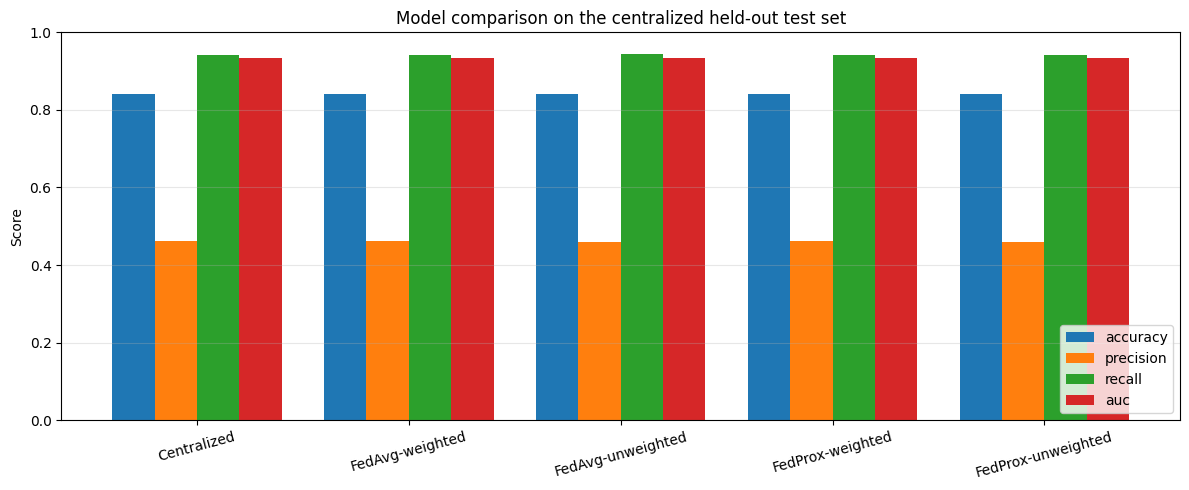

In [ ]:
metrics = ["accuracy", "precision", "recall", "auc"]
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df_results))
width = 0.2
for i, m in enumerate(metrics):
    ax.bar(x + i * width, df_results[m].values, width, label=m)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(df_results.index, rotation=15)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model comparison on the centralized held-out test set")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

all models show the same picture.

### ROC curves

we also want to inspect the roc curves of the models

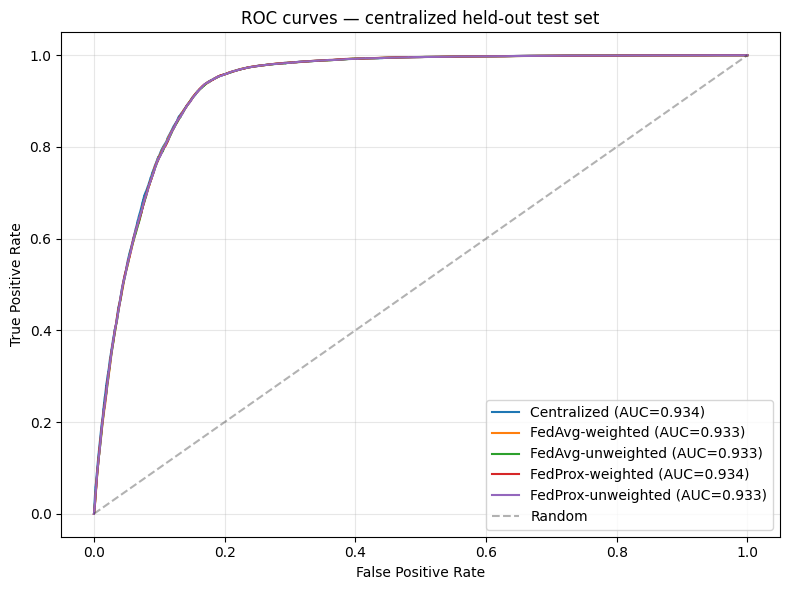

In [ ]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r["labels"], r["probs"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves — centralized held-out test set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

they are all almost exactly the same

### Precision vs. recall


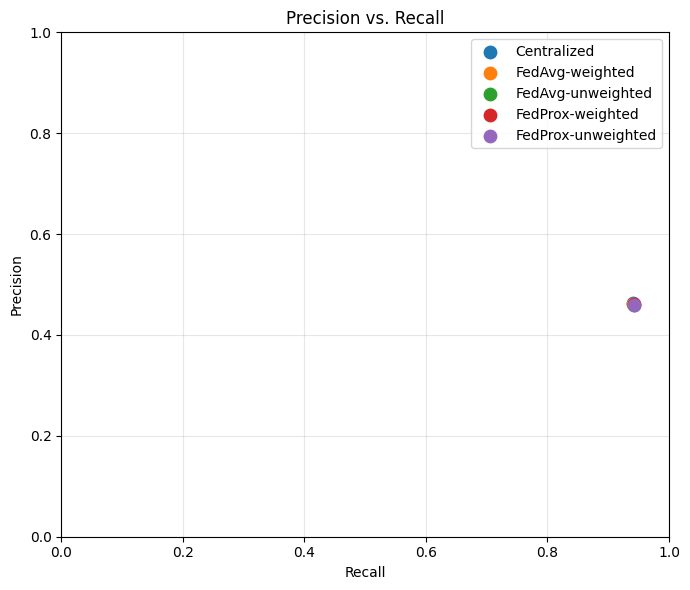

In [ ]:
plt.figure(figsize=(7, 6))
for name in df_results.index:
    plt.scatter(df_results.loc[name, "recall"], df_results.loc[name, "precision"], s=80, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Precision vs. Recall")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Conclusions


we see that all of the four federated models match the performance of the centralized baseline. All four models train with federated learning reach AUC and recall close to the baseline. so we can conclude that federated learning is a valid strategy for this problem. excluding medical unit 0 doesnt seem to impact the performance significantly. 



## 4. Limitations

- training may not be fully converged 
- unit 0 completely excluded
- each client fits its own standardscaler on the local train set. 
- we use a single pooled held out test set, which assumes that the server has access to some pooled labeled data. 


## 5. Future work

- run training until full convergence
- try other resampling / reweighting strategies to see if it impacts the performance
- evaluate per client aswell

